No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


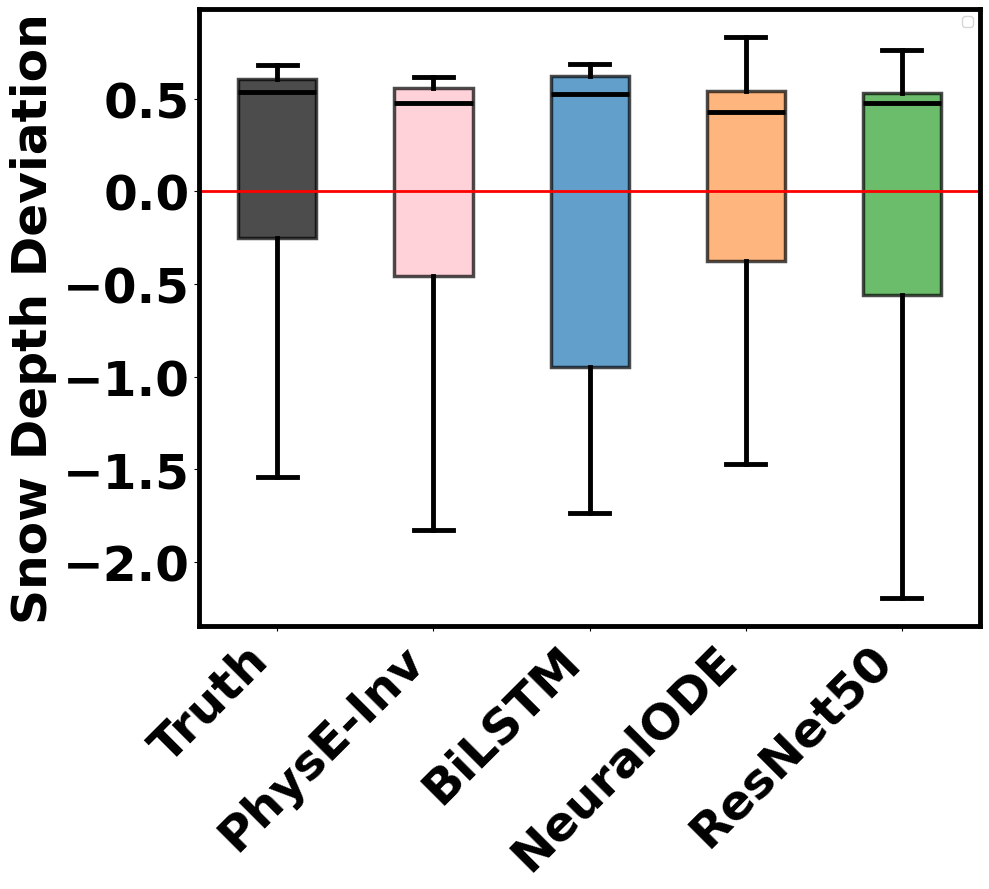

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# List of file names and corresponding model names
file_info = {
    'PhysCL-Inv-average_depths.csv': 'PhysCL-Inv',
    'BiLSTM-average_depths.csv': 'BiLSTM',
    'NeuralODE-average_depths.csv': 'NeuralODE',
    'Resnet50-average_depths.csv': 'ResNet50',
   
}

# Define colors for each model (brighter orange for NeuralODE)
model_colors = {
    'PhysCL-Inv': '#FFC0CB', # Pink
    'BiLSTM': '#1f77b4',         # Blue
    'NeuralODE': '#ff9848',       # Brighter Orange
    'ResNet50': '#2ca02c',        # Green
}

# Font sizes and colors for bold black theme
title_font_size = 28
label_font_size = 35
tick_label_size = 35
legend_font_size = 28
label_color = 'black'
tick_label_color = 'black'
axes_edge_color = 'black'
font_weight = 'bold'

# Collect anomaly data, labels, colors, and hatches for box plots (ONLY ESTIMATED)
anomaly_data_est = []
box_plot_labels_est_original = []
box_plot_colors_est = []
box_plot_hatches_est = []

# Load true values (optional)
first_file = list(file_info.keys())[0]
try:
    df_true = pd.read_csv(first_file, sep=',')
    if 'avg_true' in df_true.columns:
        anomaly_data_est.append(df_true['avg_true'].values)
        box_plot_labels_est_original.append('True')
        box_plot_colors_est.append('black')
        box_plot_hatches_est.append(None)
except FileNotFoundError:
    print(f"Warning: File '{first_file}' not found. Cannot include true anomalies in box plot.")
except Exception as e:
    print(f"Error reading '{first_file}': {e}")

# Load model estimated anomaly data
for file_name, model_name in file_info.items():
    try:
        df = pd.read_csv(file_name, sep=',')
        if 'avg_est' in df.columns:
            anomaly_data_est.append(df['avg_est'].values)
            box_plot_labels_est_original.append(f'{model_name} Est')
            box_plot_colors_est.append(model_colors.get(model_name, 'gray'))
            box_plot_hatches_est.append(None)
        else:
            print(f"Warning: Missing 'avg_est' in '{file_name}'. Skipping {model_name} for estimated box plot.")
    except FileNotFoundError:
        print(f"Error: File '{file_name}' not found.")
    except Exception as e:
        print(f"Error reading '{file_name}': {e}")

# Define the new x-axis tick labels for estimated data
new_xtick_labels_est = [
    'Truth',
    'PhysE-Inv',
    'BiLSTM',
    'NeuralODE',
    'ResNet50'
    
]

# Create the box plot for ESTIMATED values
plt.figure(figsize=(10, 9))
ax_est = plt.gca()
bp_est = plt.boxplot(anomaly_data_est, patch_artist=True, showfliers=False)

# Color and bold the box plot elements
for i, patch in enumerate(bp_est['boxes']):
    patch.set_facecolor(box_plot_colors_est[i])
    patch.set_alpha(0.7)
    # Set the box edge color and linewidth here
    patch.set_edgecolor('black')
    patch.set_linewidth(2.5)
    if box_plot_hatches_est[i]:
        patch.set_hatch(box_plot_hatches_est[i])

# Customize median lines
for median in bp_est['medians']:
    median.set(color='black', linewidth=3.5)

# Customize whisker lines
for whisker in bp_est['whiskers']:
    whisker.set(color='black', linewidth=3.5)

# Customize cap lines
for cap in bp_est['caps']:
    cap.set(color='black', linewidth=3.5)


# Draw the horizontal line for comparison
ax_est.axhline(y=0, color='red', linestyle='-', linewidth=2)

# Add a legend for the truth line
ax_est.legend(fontsize=legend_font_size, prop={'weight': font_weight})

# Set plot title and labels with bold black color and weight
#plt.title('Snow Depth', fontsize=title_font_size, color=label_color, fontweight=font_weight)
plt.ylabel('Snow Depth Deviation', fontsize=label_font_size, color=label_color, fontweight=font_weight)

# Set the x-axis tick positions and labels for estimated plots
ax_est.set_xticks(np.arange(1, len(new_xtick_labels_est) + 1))
ax_est.set_xticklabels(new_xtick_labels_est, fontsize=tick_label_size, color=tick_label_color, rotation=45, ha='right', fontweight=font_weight)

plt.yticks(fontsize=tick_label_size, color=tick_label_color, fontweight=font_weight)

# Set the color and thickness of the axes box (spines)
for spine in ax_est.spines.values():
    spine.set_edgecolor(axes_edge_color)
    spine.set_linewidth(3.5)

plt.tight_layout()
plt.savefig('Phys-Inv-anomaly_box_plot_with_truth_line.pdf', dpi=1000, bbox_inches='tight')
plt.show()

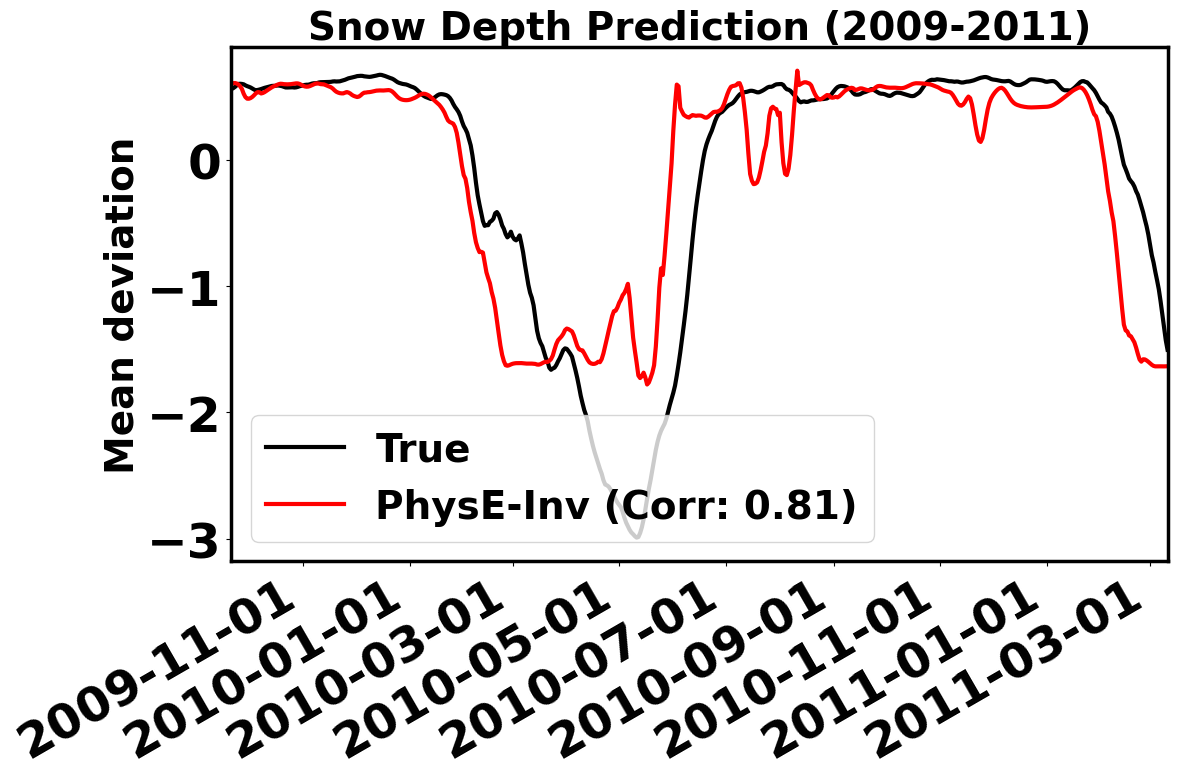

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import numpy as np
from datetime import datetime, timedelta
import matplotlib.dates as mdates

def calculate_correlation(data1, data2):
    """Calculates the Pearson correlation coefficient between two series."""
    if len(data1) != len(data2) or len(data1) < 2:
        return np.nan
    return np.corrcoef(data1, data2)[0, 1]

def create_plot():
    """Generates and saves a time series plot comparing true snow depth anomalies
       with a model's predictions (PhysCL-Inv).
    """

    # --- Configuration ---
    true_file = 'PhysCL-Inv-average_depths.csv'  # CSV with avg_true
    pred_file = 'PhysCL-Inv-average_depths.csv'  # CSV with avg_est
    model_name = 'PhysCL-Inv'

    start_date_plot = datetime(2009, 9, 21)
    end_date_plot = datetime(2011, 3, 11)
    total_days_plot = (end_date_plot - start_date_plot).days + 1
    time_plot = [start_date_plot + timedelta(days=i) for i in range(total_days_plot)]

    # Plot styling
    title_font_size = 28
    label_font_size = 28
    tick_label_size = 35
    legend_font_size = 28
    fontweight_bold = 'bold'
    label_color = 'black'
    axes_edge_color = 'black'

    fig, ax = plt.subplots(figsize=(12, 8))  # Panel size

    # --- Load True Values ---
    try:
        df_true = pd.read_csv(true_file)
        if 'avg_true' not in df_true.columns:
            raise ValueError("Column 'avg_true' not found in true CSV")
        true_values = df_true['avg_true'].values
        if len(true_values) < total_days_plot:
            # If CSV is shorter than plot range, use all available
            true_values = true_values
            plot_dates = time_plot[-len(true_values):]
        else:
            true_values = true_values[-total_days_plot:]
            plot_dates = time_plot

        ax.plot(plot_dates, true_values, label='True', color='black', linestyle='-', linewidth=3)
    except Exception as e:
        print(f"Error loading true values: {e}")
        return

    # --- Load Model Predictions ---
    try:
        df_pred = pd.read_csv(pred_file)
        if 'avg_est' not in df_pred.columns:
            raise ValueError("Column 'avg_est' not found in prediction CSV")

        pred_values = df_pred['avg_est'].values
        if len(pred_values) < len(plot_dates):
            pred_values = pred_values[-len(plot_dates):]
            plot_dates = plot_dates[-len(pred_values):]
        else:
            pred_values = pred_values[-len(plot_dates):]

        # Adjust Savitzky–Golay window
        window_length = min(11, len(pred_values) if len(pred_values) % 2 != 0 else len(pred_values)-1)
        polyorder = 2 if window_length > 2 else 1

        pred_smooth = savgol_filter(pred_values, window_length, polyorder)
        correlation = calculate_correlation(true_values[-len(pred_smooth):], pred_smooth)

        ax.plot(plot_dates, pred_smooth, label=f'PhysE-Inv (Corr: {correlation:.2f})',
                color='red', linewidth=3)

    except Exception as e:
        print(f"Error loading predictions: {e}")
        return

    # --- Plot Formatting ---
    ax.set_xlim(plot_dates[0], plot_dates[-1])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate()

    ax.set_ylabel('Mean deviation', fontsize=label_font_size, fontweight=fontweight_bold, color=label_color)
    ax.set_title(f'Snow Depth Prediction (2009-2011)', fontsize=title_font_size,
                 fontweight=fontweight_bold, color=label_color)

    ax.tick_params(axis='both', which='major', labelsize=tick_label_size, colors=label_color)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight(fontweight_bold)
        label.set_fontsize(tick_label_size)

    for spine in ax.spines.values():
        spine.set_edgecolor(axes_edge_color)
        spine.set_linewidth(2.5)

    legend = ax.legend(fontsize=legend_font_size)
    for text in legend.get_texts():
        text.set_fontweight(fontweight_bold)

    plt.tight_layout()
    plt.savefig('PhysE-Inv_comparison_clean.pdf', dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == '__main__':
    create_plot()


Pearson Correlation (True vs PhysE-Inv): 0.811


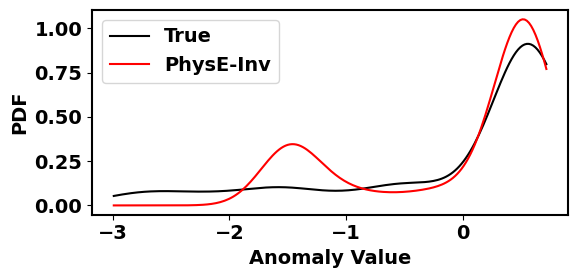

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import numpy as np
from scipy.stats import gaussian_kde
from datetime import datetime, timedelta
import matplotlib.dates as mdates

def calculate_correlation(data1, data2):
    if len(data1) != len(data2) or len(data1) < 2:
        return np.nan
    return np.corrcoef(data1, data2)[0, 1]

# File setup
file_info = {
    'BiLSTM-average_depths.csv': 'BiLSTM',
    'NeuralODE-average_depths.csv': 'NeuralODE',
    'Resnet50-average_depths.csv': 'ResNet50',
    'PhysCL-Inv-average_depths.csv': 'PhysCL-Inv'
}

start_date_plot = datetime(2009, 9, 21)
end_date_plot = datetime(2011, 3, 11)
total_days_plot = (end_date_plot - start_date_plot).days + 1
time_plot = [start_date_plot + timedelta(days=i) for i in range(total_days_plot)]

window_length, polyorder = 11, 2
fontsize = 14
fontweight = 'bold'
label_color = 'black'
axes_color = 'black'

fig, ax = plt.subplots(1, 1, figsize=(6, 3))  # Only one subplot

# Load true values
first_file = list(file_info.keys())[0]
true_values = None
try:
    df_true = pd.read_csv(first_file)
    if 'avg_true' in df_true.columns and len(df_true) >= total_days_plot:
        true_values = df_true['avg_true'].iloc[-total_days_plot:].values
except Exception as e:
    print(f"Error loading true values: {e}")

# Load PhysCL-Inv predictions
physcl_avg_smooth = None
try:
    df_physcl = pd.read_csv('PhysCL-Inv-average_depths.csv')
    if 'avg_est' in df_physcl.columns and 'avg_pred' in df_physcl.columns and len(df_physcl) >= total_days_plot:
        est = savgol_filter(df_physcl['avg_est'], window_length, polyorder)[-total_days_plot:]
        pred = savgol_filter(df_physcl['avg_pred'], window_length, polyorder)[-total_days_plot:]
        physcl_avg_smooth = (est + pred) / 2
except Exception as e:
    print(f"Error loading PhysCL-Inv data: {e}")

# Plot KDEs in the single subplot (ax)
if true_values is not None and physcl_avg_smooth is not None:
    x_vals = np.linspace(min(true_values.min(), physcl_avg_smooth.min()),
                         max(true_values.max(), physcl_avg_smooth.max()), 200)
    kde_true = gaussian_kde(true_values)(x_vals)
    kde_physcl = gaussian_kde(physcl_avg_smooth)(x_vals)
    ax.plot(x_vals, kde_true, color='black', label='True')
    ax.plot(x_vals, kde_physcl, color='red', label='PhysE-Inv')
    #ax.set_title('Probability Density Function (PDF) of Anomalies', fontsize=fontsize, fontweight=fontweight)
    ax.set_xlabel('Anomaly Value', fontsize=fontsize, fontweight=fontweight)
    ax.set_ylabel('PDF', fontsize=fontsize, fontweight=fontweight)
    ax.legend(fontsize=6)
    corr = calculate_correlation(true_values, physcl_avg_smooth)
    print(f"Pearson Correlation (True vs PhysE-Inv): {corr:.3f}")

# Style the single subplot (ax)
ax.tick_params(axis='both', labelsize=fontsize)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight(fontweight)
legend = ax.legend(fontsize=fontsize)
for text in legend.get_texts():
    text.set_fontweight(fontweight)
    text.set_fontsize(fontsize)

for spine in ax.spines.values():
    spine.set_edgecolor(axes_color)
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig('Phys-Inv-pdf_only_plot.png', dpi=300, bbox_inches='tight')
plt.show()

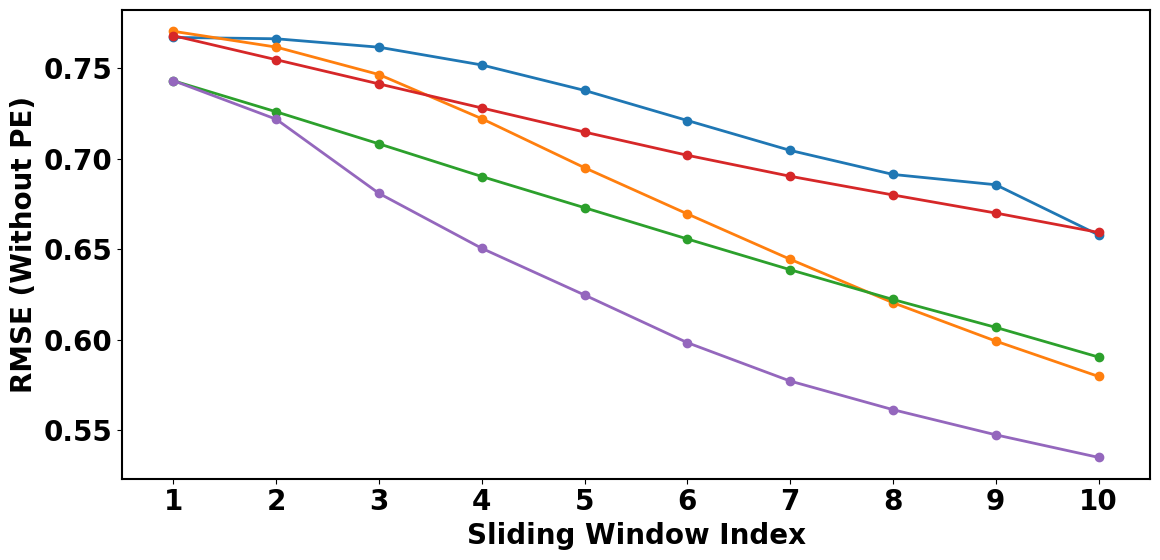

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define file names and labels
files = {
    'BiLSTM': 'BiLSTM-rmse_values.csv',
    'LSTM': 'LSTM-rmse_values.csv',
    'ResNet50': 'Resnet50-rmse_values.csv',
    'NeuralODE': 'NeuralODE-rmse_values.csv',
    'PhysE-Inv': 'PhysCL-Inv-rmse_values.csv'
}

# Set a consistent font size and color for labels and title
font_size = 20
label_color = 'black'
fontweight_bold = 'bold'

plt.rcParams['font.size'] = font_size
plt.rcParams['legend.fontsize'] = font_size
plt.rcParams['legend.labelcolor'] = label_color

# Create a plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Physics RMSE for each model
for label, file in files.items():
    try:
        df = pd.read_csv(file, sep=',') 
        phys_rmse = df['rmse_lstm_per_t']  
        
        # FIX: Create a time axis starting at 1 instead of 0
        timesteps = np.arange(1, len(phys_rmse) + 1)  

        ax.plot(timesteps, phys_rmse, linestyle='-', marker='o', label=f'{label}', linewidth=2)
    except FileNotFoundError:
        print(f"Warning: {file} not found. Skipping {label}.")

# --- Labeling and Axis Formatting ---
ax.set_xlabel('Sliding Window Index', fontsize=font_size, color=label_color, fontweight=fontweight_bold)
ax.set_ylabel('RMSE (Without PE)', fontsize=font_size, color=label_color, fontweight=fontweight_bold)

# FIX: Set explicit ticks from 1 to 10 and adjust limits so markers aren't cut off
ax.set_xticks(np.arange(1, 11))
ax.set_xlim(0.5, 10.5) 

# Make legend labels bold
#legend = ax.legend(loc='upper right', prop={'weight': fontweight_bold})
#for text in legend.get_texts():
#    text.set_fontweight(fontweight_bold)

# Make tick labels bold
ax.tick_params(axis='both', which='major', labelsize=font_size, color=label_color)
for label in ax.get_xticklabels():
    label.set_fontweight(fontweight_bold)
for label in ax.get_yticklabels():
    label.set_fontweight(fontweight_bold)

# Make the axes spines (window lines) bold
for spine in ax.spines:
    ax.spines[spine].set_linewidth(1.5)

plt.tight_layout()
plt.savefig('PhysE-Inv-rmse_comparison_final.png', dpi=300, bbox_inches='tight')
plt.show()

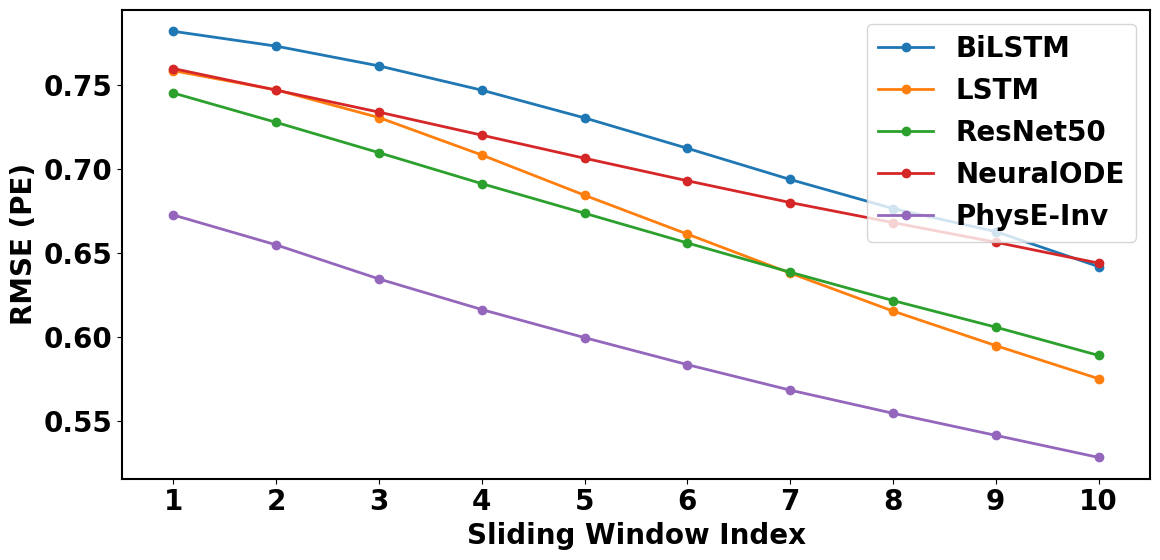

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define file names and labels
files = {
    'BiLSTM': 'BiLSTM-rmse_values.csv',
    'LSTM': 'LSTM-rmse_values.csv',
    'ResNet50': 'Resnet50-rmse_values.csv',
    'NeuralODE': 'NeuralODE-rmse_values.csv',
    'PhysE-Inv': 'PhysCL-Inv-rmse_values.csv'
}

# Set a consistent font size and color for labels and title
font_size = 20
label_color = 'black'
fontweight_bold = 'bold'

plt.rcParams['font.size'] = font_size
plt.rcParams['legend.fontsize'] = font_size
plt.rcParams['legend.labelcolor'] = label_color

# Create a plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Physics RMSE for each model
for label, file in files.items():
    try:
        df = pd.read_csv(file, sep=',') 
        phys_rmse = df['rmse_phys_per_t']  
        
        # FIX: Create a time axis starting at 1 instead of 0
        timesteps = np.arange(1, len(phys_rmse) + 1)  

        ax.plot(timesteps, phys_rmse, linestyle='-', marker='o', label=f'{label}', linewidth=2)
    except FileNotFoundError:
        print(f"Warning: {file} not found. Skipping {label}.")

# --- Labeling and Axis Formatting ---
ax.set_xlabel('Sliding Window Index', fontsize=font_size, color=label_color, fontweight=fontweight_bold)
ax.set_ylabel('RMSE (PE)', fontsize=font_size, color=label_color, fontweight=fontweight_bold)

# FIX: Set explicit ticks from 1 to 10 and adjust limits so markers aren't cut off
ax.set_xticks(np.arange(1, 11))
ax.set_xlim(0.5, 10.5) 

# Make legend labels bold
legend = ax.legend(loc='upper right', prop={'weight': fontweight_bold})
for text in legend.get_texts():
    text.set_fontweight(fontweight_bold)

# Make tick labels bold
ax.tick_params(axis='both', which='major', labelsize=font_size, color=label_color)
for label in ax.get_xticklabels():
    label.set_fontweight(fontweight_bold)
for label in ax.get_yticklabels():
    label.set_fontweight(fontweight_bold)

# Make the axes spines (window lines) bold
for spine in ax.spines:
    ax.spines[spine].set_linewidth(1.5)

plt.tight_layout()
plt.savefig('PhysE-Inv-rmse_comparison_final.png', dpi=300, bbox_inches='tight')
plt.show()